In [1]:
import joblib

rf = joblib.load("rf_model.pkl")
feature_columns = joblib.load("feature_columns.pkl")

In [2]:
import pandas as pd
import joblib
from sklearn.metrics import classification_report, confusion_matrix

# Load trained model + feature columns
rf = joblib.load("rf_model.pkl")
feature_columns = joblib.load("feature_columns.pkl")

# Define paths
TEST_PATH = r"test\test.csv"

# Zero-day attacks (same as before)
ZERO_DAY_ATTACKS = {
    "SqlInjection",
    "XSS",
    "CommandInjection",
    "BrowserHijacking",
    "Uploading_Attack",
    "Backdoor_Malware",
    "DictionaryBruteForce",
}

# Helper functions
def make_binary_y(label):
    return 0 if label == "BenignTraffic" else 1

def prepare_xy(df):
    y = df["y"].astype(int)
    X = df.drop(columns=["label", "y"], errors="ignore")
    X = X.apply(pd.to_numeric, errors="coerce").fillna(0)
    return X, y

# Load test data in chunks
CHUNKSIZE = 250_000
MAX_TEST_ROWS = 200_000

test_parts = []
test_count = 0

for chunk in pd.read_csv(TEST_PATH, chunksize=CHUNKSIZE):
    chunk["y"] = chunk["label"].apply(make_binary_y)

    is_zero_day = chunk["label"].isin(ZERO_DAY_ATTACKS)
    is_benign = chunk["label"].eq("BenignTraffic")

    selected = chunk[is_zero_day | is_benign]

    if len(selected) > 0:
        remaining = MAX_TEST_ROWS - test_count

        if len(selected) > remaining:
            selected = selected.sample(n=remaining, random_state=42)

        test_parts.append(selected)
        test_count += len(selected)

    if test_count >= MAX_TEST_ROWS:
        break

# Combine all chunks
final_test_df = pd.concat(test_parts, ignore_index=True)

print("Final test shape:", final_test_df.shape)

# Prepare data
X_final_test, y_final_test = prepare_xy(final_test_df)

# IMPORTANT: match training feature order
X_final_test = X_final_test[feature_columns]

# Predict
final_pred = rf.predict(X_final_test)

# Results
print("\nClass distribution:")
print(y_final_test.value_counts())

print("\nConfusion Matrix:")
print(confusion_matrix(y_final_test, final_pred))

print("\nClassification Report:")
print(classification_report(y_final_test, final_pred, digits=4))

Final test shape: (28654, 48)

Class distribution:
y
0    27709
1      945
Name: count, dtype: int64

Confusion Matrix:
[[26143  1566]
 [   79   866]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9970    0.9435    0.9695     27709
           1     0.3561    0.9164    0.5129       945

    accuracy                         0.9426     28654
   macro avg     0.6765    0.9299    0.7412     28654
weighted avg     0.9759    0.9426    0.9544     28654



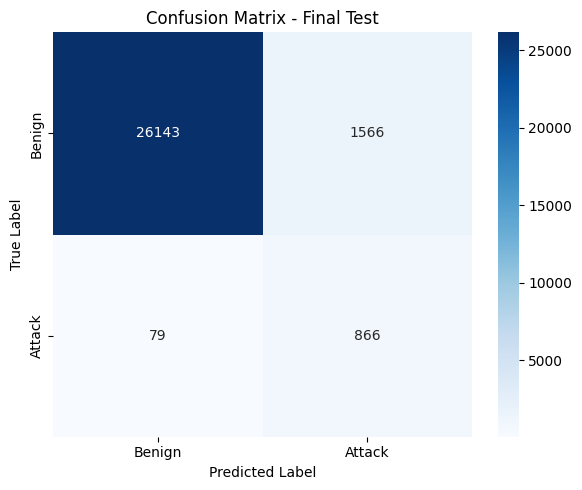

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_final_test, final_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Attack'],
            yticklabels=['Benign', 'Attack'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Final Test')
plt.tight_layout()

plt.savefig('cm_final.png', dpi=300, bbox_inches='tight')
plt.show()

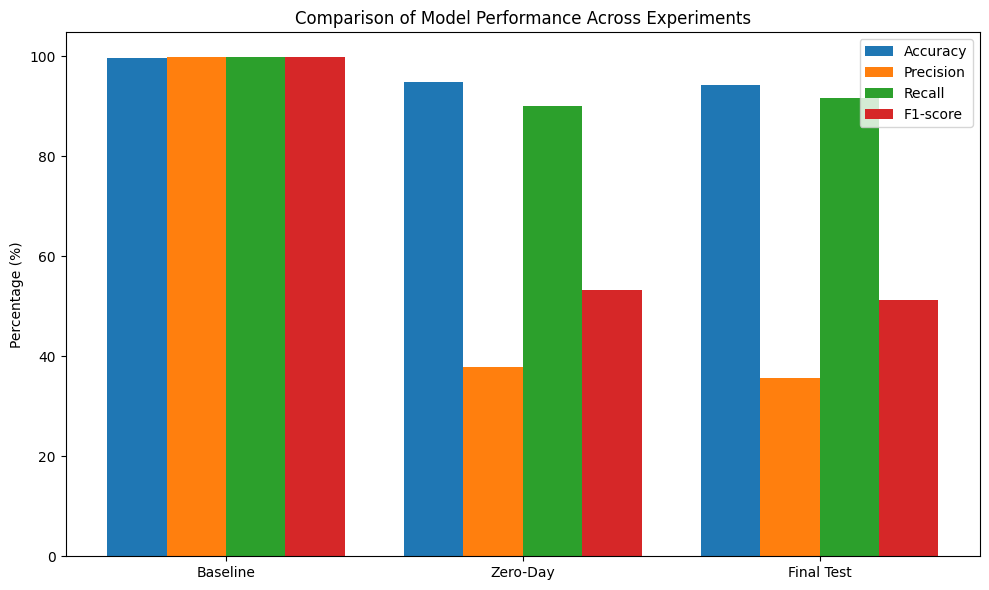

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Data from your results
experiments = ['Baseline', 'Zero-Day', 'Final Test']
accuracy = [99.7, 94.86, 94.26]
precision = [99.8, 37.83, 35.61]
recall = [99.8, 90.05, 91.64]
f1 = [99.8, 53.28, 51.29]

x = np.arange(len(experiments))
width = 0.2

plt.figure(figsize=(10,6))

plt.bar(x - width*1.5, accuracy, width, label='Accuracy')
plt.bar(x - width*0.5, precision, width, label='Precision')
plt.bar(x + width*0.5, recall, width, label='Recall')
plt.bar(x + width*1.5, f1, width, label='F1-score')

plt.xticks(x, experiments)
plt.ylabel('Percentage (%)')
plt.title('Comparison of Model Performance Across Experiments')
plt.legend()

plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=300)
plt.show()